# Thực nghiệm Lựa Chọn Ngưỡng Phát Hiện Bất Thường (Threshold Experiment)

## Mục tiêu

Nghiên cứu **ảnh hưởng của percentile threshold** đến hiệu năng phát hiện bất thường trong hệ thống NIDS-VAE.

Kết quả notebook này phục vụ **Chương 4** của báo cáo: chứng minh lý do chọn threshold và so sánh các mức ngưỡng.

---

## Thiết kế thí nghiệm

| Experiment | Percentile | Mô tả |
|---|---|---|
| A | 90 | Ngưỡng thấp — phát hiện nhạy, nhiều false alarm |
| B | 95 | Ngưỡng trung bình — cân bằng Precision/Recall |
| C | 99 | Ngưỡng cao — chính xác, dễ bỏ sót attack |

**Lưu ý:**
- Không train lại model — chỉ sử dụng `vae_best.pth` đã có.
- Threshold được tính từ phân phối reconstruction error trên **tập validation BENIGN**.
- Đánh giá trên **tập test** (chứa cả normal và anomaly traffic).

---

## Section 1 — Giới Thiệu Thí Nghiệm

### Threshold trong Anomaly Detection là gì?

Trong hệ thống NIDS-VAE, **threshold (ngưỡng phát hiện)** là một giá trị số thực dùng để phân loại mỗi flow mạng:

$$
\text{reconstruction error} > \text{threshold} \Rightarrow \text{ANOMALY}
$$
$$
\text{reconstruction error} \leq \text{threshold} \Rightarrow \text{NORMAL}
$$

### Reconstruction Error là gì?

VAE được huấn luyện chỉ trên **traffic bình thường (BENIGN)**. Khi một flow bất thường được đưa vào, VAE không thể tái tạo tốt → **reconstruction error cao**.

$$
\text{error}_i = \frac{1}{d} \sum_{j=1}^{d} (x_{ij} - \hat{x}_{ij})^2 \quad \text{(MSE per sample)}
$$

### Quan hệ giữa Threshold và Hiệu năng

```
Threshold THẤP (P90)
→ Dễ báo động
→ Nhiều flow bị đánh dấu là bất thường
→ Recall cao (phát hiện nhiều attack hơn)
→ FPR cao (nhiều false alarm hơn)

Threshold CAO (P99)
→ Khó báo động
→ Chỉ những flow RẤT khác biệt mới bị đánh dấu
→ Precision cao (ít false alarm hơn)
→ FNR cao (bỏ sót nhiều attack hơn)
```

### Tại sao chọn threshold từ Validation BENIGN?

- **Không rò rỉ thông tin** từ tập test vào quyết định ngưỡng.
- Tập validation chỉ chứa BENIGN → percentile phản ánh phân phối "normal error".
- Percentile p% nghĩa là: "p% flow bình thường có error thấp hơn ngưỡng này".

---

## Section 2 — Import Thư Viện và Thiết Lập Môi Trường

In [8]:
# ── Import thư viện chuẩn ──────────────────────────────────────────────────
import json
import logging
import sys
from pathlib import Path

# ── Import thư viện khoa học dữ liệu ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import gaussian_kde

# ── Import PyTorch ─────────────────────────────────────────────────────────
import torch
from torch.utils.data import DataLoader, TensorDataset

# ── Import scikit-learn metrics ────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ── Thiết lập đường dẫn gốc project ───────────────────────────────────────
# Notebook nằm trong notebooks/, PROJECT_ROOT là thư mục cha
PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Đường dẫn artifacts đầu vào
ARTIFACTS_DIR      = PROJECT_ROOT / "artifacts"
MODEL_CONFIG_PATH  = ARTIFACTS_DIR / "models" / "model_config.json"
MODEL_CHECKPOINT   = ARTIFACTS_DIR / "models" / "vae_best.pth"
SCALER_PATH        = ARTIFACTS_DIR / "scaler" / "scaler.joblib"

# Đường dẫn dữ liệu
DATA_VAL_DIR  = PROJECT_ROOT / "data" / "validation"
DATA_TEST_DIR = PROJECT_ROOT / "data" / "test"

# Thư mục lưu kết quả thí nghiệm
OUTPUT_DIR = ARTIFACTS_DIR / "experiments" / "threshold"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Cấu hình matplotlib ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_style("whitegrid")

# ── Cấu hình logging ────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("threshold_experiment")

# Chọn device: GPU nếu có, ngược lại CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4096  # Kích thước batch khi chạy inference

print(f"✅ Project root: {PROJECT_ROOT}")
print(f"✅ Device: {DEVICE}")
print(f"✅ Output dir: {OUTPUT_DIR}")

✅ Project root: D:\nids-vae-project
✅ Device: cpu
✅ Output dir: D:\nids-vae-project\artifacts\experiments\threshold


---

## Section 3 — Load Model và Dữ Liệu

Load checkpoint VAE tốt nhất, tập validation BENIGN và tập test đầy đủ.

In [9]:
# ── Import kiến trúc VAE từ backend ────────────────────────────────────────
# Dùng chung kiến trúc với training và inference — không tạo lại
from backend.app.models.vae import VAE


def load_vae_model(config_path: Path, checkpoint_path: Path, device: torch.device) -> tuple[VAE, dict]:
    """
    Tải VAE từ config và checkpoint đã lưu.

    Quy trình:
    1. Đọc model_config.json để lấy kiến trúc (input_dim, latent_dim, hidden_dims)
    2. Khởi tạo VAE với cùng kiến trúc huấn luyện
    3. Nạp weights từ vae_best.pth
    4. Chuyển sang eval mode (reparameterize dùng mu, không sampling)

    Returns:
        (model, config_dict)
    """
    # Đọc cấu hình kiến trúc
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    input_dim   = config["input_dim"]
    latent_dim  = config["latent_dim"]
    hidden_dims = config["hidden_dims"]

    logger.info("Cấu hình model: input_dim=%d, latent_dim=%d, hidden_dims=%s",
                input_dim, latent_dim, hidden_dims)

    # Tái tạo kiến trúc VAE và nạp weights
    model = VAE(input_dim=input_dim, latent_dim=latent_dim, hidden_dims=hidden_dims)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()  # Inference mode: z = mu (deterministic)

    logger.info("✅ Đã load checkpoint: %s", checkpoint_path.name)
    return model, config


@torch.no_grad()
def compute_reconstruction_errors(
    model: VAE,
    X: np.ndarray,
    batch_size: int,
    device: torch.device,
) -> np.ndarray:
    """
    Tính MSE reconstruction error cho từng mẫu.

    Công thức nhất quán với scripts/evaluate.py và backend inference:
        error_i = mean((x_i - x̂_i)²)  theo chiều feature

    Args:
        model      : VAE ở eval mode
        X          : Ma trận dữ liệu (n_samples, input_dim)
        batch_size : Kích thước batch
        device     : Thiết bị tính toán

    Returns:
        Mảng numpy (n_samples,) chứa reconstruction error từng mẫu
    """
    tensor_X = torch.tensor(X, dtype=torch.float32)
    dataset  = TensorDataset(tensor_X)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_errors = []
    for (batch,) in loader:
        batch = batch.to(device)
        x_hat, _mu, _logvar = model(batch)
        # Dùng static method của VAE class — nhất quán với backend
        errors = VAE.reconstruction_error(batch, x_hat)
        all_errors.append(errors.cpu().numpy())

    return np.concatenate(all_errors, axis=0)


# ── Load model ─────────────────────────────────────────────────────────────
model, model_config = load_vae_model(MODEL_CONFIG_PATH, MODEL_CHECKPOINT, DEVICE)
print(f"\n📦 Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"   input_dim={model_config['input_dim']}, latent_dim={model_config['latent_dim']}, "
      f"hidden_dims={model_config['hidden_dims']}")

# ── Load dữ liệu ───────────────────────────────────────────────────────────
logger.info("Đang tải validation set và test set...")
X_val  = np.load(DATA_VAL_DIR  / "X_val.npy")
y_val  = np.load(DATA_VAL_DIR  / "y_val.npy")
X_test = np.load(DATA_TEST_DIR / "X_test.npy")
y_test = np.load(DATA_TEST_DIR / "y_test.npy")

# Kiểm tra shape và phân phối nhãn
print(f"\n📊 Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"   Phân phối: BENIGN={int((y_val==0).sum()):,}, ANOMALY={int((y_val==1).sum()):,}")
print(f"\n📊 Test set: X={X_test.shape}, y={y_test.shape}")
n_normal  = int((y_test == 0).sum())
n_anomaly = int((y_test == 1).sum())
print(f"   Phân phối: NORMAL={n_normal:,} ({n_normal/len(y_test)*100:.1f}%), "
      f"ANOMALY={n_anomaly:,} ({n_anomaly/len(y_test)*100:.1f}%)")

# Xác nhận không có NaN hoặc Inf
assert not np.isnan(X_val).any() and not np.isinf(X_val).any(), "X_val chứa NaN hoặc Inf!"
assert not np.isnan(X_test).any() and not np.isinf(X_test).any(), "X_test chứa NaN hoặc Inf!"
print("\n✅ Dữ liệu hợp lệ — không có NaN/Inf")

13:22:46 [INFO] Cấu hình model: input_dim=66, latent_dim=16, hidden_dims=[128, 64]
13:22:46 [INFO] ✅ Đã load checkpoint: vae_best.pth
13:22:46 [INFO] Đang tải validation set và test set...



📦 Model params: 36,834
   input_dim=66, latent_dim=16, hidden_dims=[128, 64]

📊 Validation set: X=(100558, 66), y=(100558,)
   Phân phối: BENIGN=100,558, ANOMALY=0

📊 Test set: X=(2019575, 66), y=(2019575,)
   Phân phối: NORMAL=1,593,697 (78.9%), ANOMALY=425,878 (21.1%)

✅ Dữ liệu hợp lệ — không có NaN/Inf


In [10]:
# ── Tính reconstruction error trên validation và test set ─────────────────
# CHỈ tính một lần — dùng lại cho tất cả các thí nghiệm
logger.info("Tính reconstruction error trên validation set...")
errors_val = compute_reconstruction_errors(model, X_val, BATCH_SIZE, DEVICE)

logger.info("Tính reconstruction error trên test set...")
errors_test = compute_reconstruction_errors(model, X_test, BATCH_SIZE, DEVICE)

# Tách errors của BENIGN validation (dùng để tính threshold)
# y_val = 0 là BENIGN (bình thường), y_val = 1 là anomaly (nếu có)
errors_val_benign = errors_val[y_val == 0]

print(f"\n📈 Validation BENIGN errors: n={len(errors_val_benign):,}")
print(f"   mean={errors_val_benign.mean():.4f}, std={errors_val_benign.std():.4f}")
print(f"   min={errors_val_benign.min():.4f}, max={errors_val_benign.max():.4f}")
print(f"\n📈 Test errors: n={len(errors_test):,}")
print(f"   mean={errors_test.mean():.4f}, std={errors_test.std():.4f}")

13:22:47 [INFO] Tính reconstruction error trên validation set...
13:22:48 [INFO] Tính reconstruction error trên test set...



📈 Validation BENIGN errors: n=100,558
   mean=0.6354, std=2.4332
   min=0.0099, max=631.3644

📈 Test errors: n=2,019,575
   mean=3.5238, std=147.3522


---

## Section 4 — Phân Tích Phân Bố Reconstruction Error

Vẽ histogram và KDE (Kernel Density Estimate) của reconstruction error trên tập **validation BENIGN**.

Đánh dấu các mốc percentile P90, P95, P99 để trực quan hóa vị trí threshold.

Percentile 90 → threshold = 1.334187
Percentile 95 → threshold = 2.871651
Percentile 99 → threshold = 6.031263


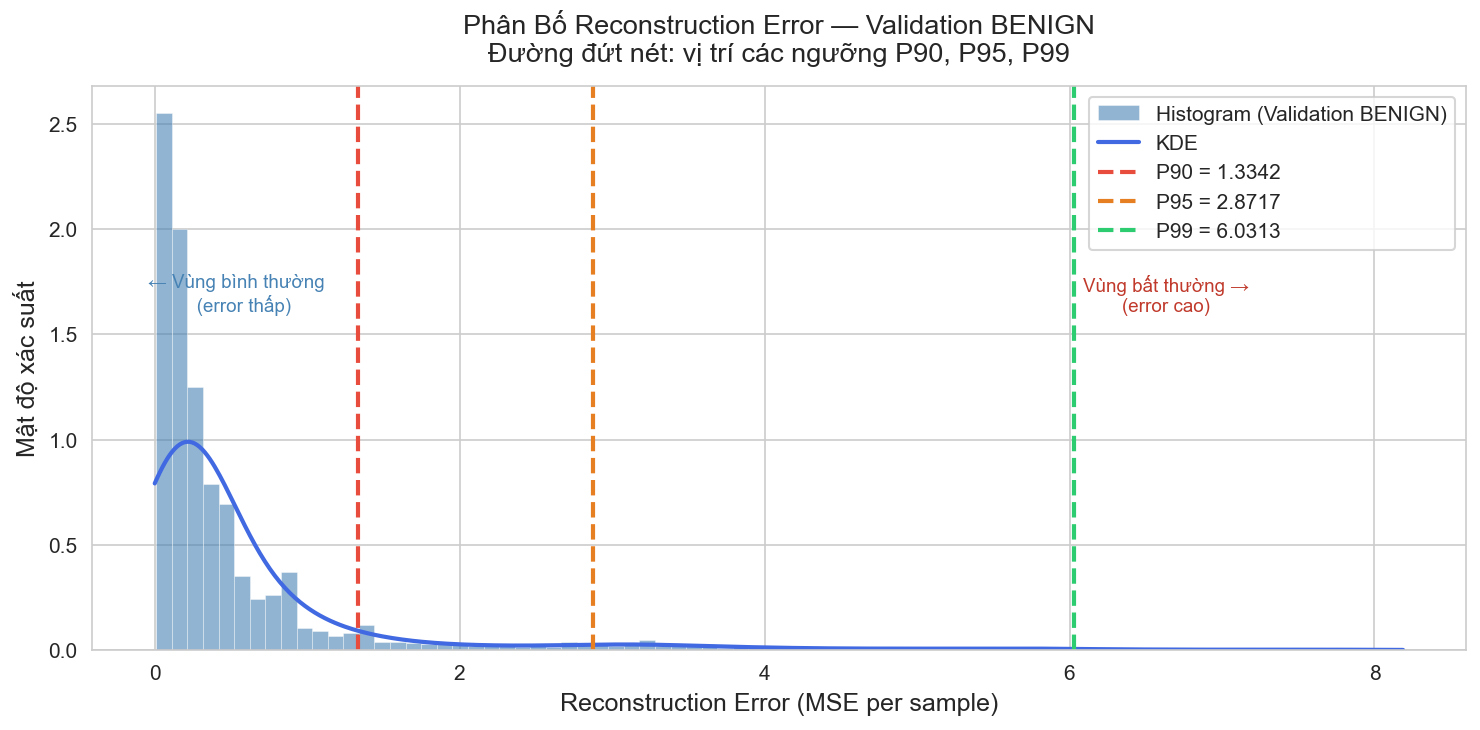


✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\error_distribution.png


In [11]:
# ── Tính các mốc percentile từ validation BENIGN errors ───────────────────
p90 = float(np.percentile(errors_val_benign, 90))
p95 = float(np.percentile(errors_val_benign, 95))
p99 = float(np.percentile(errors_val_benign, 99))

print(f"Percentile 90 → threshold = {p90:.6f}")
print(f"Percentile 95 → threshold = {p95:.6f}")
print(f"Percentile 99 → threshold = {p99:.6f}")

# ── Vẽ histogram + KDE phân phối reconstruction error ─────────────────────
# Clip dữ liệu để loại bỏ outlier cực đoan khi vẽ (chỉ ảnh hưởng trực quan)
plot_cap = np.percentile(errors_val_benign, 99.5)
data_for_plot = errors_val_benign[errors_val_benign <= plot_cap]

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram phân phối error
ax.hist(data_for_plot, bins=80, density=True,
        color="steelblue", alpha=0.6, label="Histogram (Validation BENIGN)", edgecolor="white", linewidth=0.3)

# KDE curve để làm mịn phân phối
try:
    kde = gaussian_kde(data_for_plot, bw_method=0.3)
    x_grid = np.linspace(0, plot_cap, 500)
    ax.plot(x_grid, kde(x_grid), color="royalblue", linewidth=2, label="KDE")
except Exception:
    pass  # Bỏ qua nếu KDE lỗi

# Đánh dấu các ngưỡng percentile
threshold_colors = {"P90": ("#e74c3c", p90), "P95": ("#e67e22", p95), "P99": ("#2ecc71", p99)}
for label, (color, val) in threshold_colors.items():
    ax.axvline(val, color=color, linestyle="--", linewidth=2,
               label=f"{label} = {val:.4f}")

# Tiêu đề và nhãn
ax.set_title("Phân Bố Reconstruction Error — Validation BENIGN\n"
             "Đường đứt nét: vị trí các ngưỡng P90, P95, P99", pad=12)
ax.set_xlabel("Reconstruction Error (MSE per sample)")
ax.set_ylabel("Mật độ xác suất")
ax.legend(loc="upper right")

# Chú thích vùng "bình thường" và "bất thường"
ax.annotate("← Vùng bình thường\n   (error thấp)",
            xy=(p90 * 0.4, ax.get_ylim()[1] * 0.6),
            fontsize=9, color="steelblue", ha="center")
ax.annotate("Vùng bất thường →\n(error cao)",
            xy=(p99 * 1.1, ax.get_ylim()[1] * 0.6),
            fontsize=9, color="#c0392b", ha="center")

plt.tight_layout()

# Lưu hình vào thư mục experiments
output_path = OUTPUT_DIR / "error_distribution.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Đã lưu: {output_path}")

---

## Section 5 — Tính Threshold Theo Percentile

Tính chính xác giá trị threshold cho từng mức percentile và lưu thành CSV phục vụ báo cáo.

In [12]:
# ── Định nghĩa bộ thí nghiệm ──────────────────────────────────────────────
# Mỗi thí nghiệm chỉ khác nhau ở percentile — model và dữ liệu giữ nguyên
EXPERIMENTS = [
    {"percentile": 90, "threshold": p90},
    {"percentile": 95, "threshold": p95},
    {"percentile": 99, "threshold": p99},
]

# ── Tạo DataFrame bảng threshold ──────────────────────────────────────────
df_thresholds = pd.DataFrame(EXPERIMENTS)
df_thresholds.columns = ["Percentile", "Threshold"]
df_thresholds["Threshold"] = df_thresholds["Threshold"].round(6)

print("📋 Bảng Threshold theo Percentile:")
print(df_thresholds.to_string(index=False))

# ── Xuất file CSV ──────────────────────────────────────────────────────────
threshold_csv_path = OUTPUT_DIR / "threshold_values.csv"
df_thresholds.to_csv(threshold_csv_path, index=False, encoding="utf-8")
print(f"\n✅ Đã lưu: {threshold_csv_path}")

📋 Bảng Threshold theo Percentile:
 Percentile  Threshold
         90   1.334187
         95   2.871651
         99   6.031263

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\threshold_values.csv


---

## Section 6 — Đánh Giá Hiệu Năng Theo Từng Threshold

Với mỗi threshold, phân loại từng flow trong test set thành NORMAL hoặc ANOMALY rồi tính đầy đủ metrics.

In [13]:
def evaluate_threshold(
    errors: np.ndarray,
    y_true: np.ndarray,
    threshold: float,
) -> dict:
    """
    Đánh giá hiệu năng phân loại anomaly với một ngưỡng cho trước.

    Quy tắc phân loại (nhất quán với CLAUDE.md):
        error > threshold  →  1 (ANOMALY)
        error ≤ threshold  →  0 (NORMAL)

    Tính các metric:
        - Accuracy, Precision, Recall, F1-score
        - ROC-AUC (dùng score liên tục)
        - False Positive Rate = FP / (FP + TN)
        - False Negative Rate = FN / (FN + TP)
        - Confusion matrix components: TP, TN, FP, FN

    Args:
        errors    : Mảng reconstruction error (n_samples,)
        y_true    : Nhãn thực (0=normal, 1=anomaly)
        threshold : Ngưỡng phân loại

    Returns:
        Dict chứa tất cả metrics và confusion matrix
    """
    # Phân loại theo ngưỡng
    y_pred = (errors > threshold).astype(int)

    # Tính confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Tính các tỷ lệ lỗi
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0  # Tỷ lệ báo động nhầm
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0  # Tỷ lệ bỏ sót attack

    return {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, errors)),
        "fpr":       fpr,
        "fnr":       fnr,
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
        "n_predicted_anomaly": int(y_pred.sum()),
        "n_predicted_normal":  int((y_pred == 0).sum()),
    }


# ── Chạy đánh giá cho từng thí nghiệm ────────────────────────────────────
results = []
confusion_matrices = {}

for exp in EXPERIMENTS:
    pct = exp["percentile"]
    thr = exp["threshold"]

    metrics = evaluate_threshold(errors_test, y_test, thr)
    metrics["percentile"] = pct
    metrics["threshold"]  = thr
    results.append(metrics)
    confusion_matrices[pct] = confusion_matrix(y_test, (errors_test > thr).astype(int), labels=[0, 1])

    print(f"\n{'='*55}")
    print(f"  Experiment P{pct}  |  threshold = {thr:.6f}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.2f}%)")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-score  : {metrics['f1']:.4f}")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")
    print(f"  FPR       : {metrics['fpr']:.4f}  ({metrics['fpr']*100:.2f}%)")
    print(f"  FNR       : {metrics['fnr']:.4f}  ({metrics['fnr']*100:.2f}%)")
    print(f"  TP={metrics['tp']:,}  TN={metrics['tn']:,}  FP={metrics['fp']:,}  FN={metrics['fn']:,}")


  Experiment P90  |  threshold = 1.334187
  Accuracy  : 0.8201  (82.01%)
  Precision : 0.5685
  Recall    : 0.6099
  F1-score  : 0.5885
  ROC-AUC   : 0.7835
  FPR       : 0.1237  (12.37%)
  FNR       : 0.3901  (39.01%)
  TP=259,746  TN=1,396,563  FP=197,134  FN=166,132

  Experiment P95  |  threshold = 2.871651
  Accuracy  : 0.8608  (86.08%)
  Precision : 0.7013
  Recall    : 0.5917
  F1-score  : 0.6419
  ROC-AUC   : 0.7835
  FPR       : 0.0673  (6.73%)
  FNR       : 0.4083  (40.83%)
  TP=251,999  TN=1,486,374  FP=107,323  FN=173,879

  Experiment P99  |  threshold = 6.031263
  Accuracy  : 0.8920  (89.20%)
  Precision : 0.8654
  Recall    : 0.5778
  F1-score  : 0.6929
  ROC-AUC   : 0.7835
  FPR       : 0.0240  (2.40%)
  FNR       : 0.4222  (42.22%)
  TP=246,075  TN=1,555,423  FP=38,274  FN=179,803


---

## Section 7 — Bảng So Sánh Tổng Hợp

Tổng hợp tất cả kết quả vào một bảng duy nhất và xuất ra file CSV.

In [14]:
# ── Tạo DataFrame tổng hợp ────────────────────────────────────────────────
df_results = pd.DataFrame(results)

# Chọn và sắp xếp các cột hiển thị cho báo cáo
display_cols = ["percentile", "threshold", "precision", "recall", "f1",
                "roc_auc", "fpr", "fnr", "accuracy",
                "tp", "tn", "fp", "fn"]
df_display = df_results[display_cols].copy()

# Định dạng tên cột đẹp hơn
df_display.columns = ["Percentile", "Threshold", "Precision", "Recall", "F1",
                       "ROC-AUC", "FPR", "FNR", "Accuracy",
                       "TP", "TN", "FP", "FN"]

# Làm tròn số thực cho dễ đọc
float_cols = ["Threshold", "Precision", "Recall", "F1", "ROC-AUC", "FPR", "FNR", "Accuracy"]
df_display[float_cols] = df_display[float_cols].round(4)

print("📋 Bảng So Sánh Hiệu Năng Theo Percentile:")
print(df_display.to_string(index=False))

# ── Xuất file CSV cho báo cáo ─────────────────────────────────────────────
comparison_csv_path = OUTPUT_DIR / "threshold_comparison.csv"
df_display.to_csv(comparison_csv_path, index=False, encoding="utf-8")
print(f"\n✅ Đã lưu: {comparison_csv_path}")

📋 Bảng So Sánh Hiệu Năng Theo Percentile:
 Percentile  Threshold  Precision  Recall     F1  ROC-AUC    FPR    FNR  Accuracy     TP      TN     FP     FN
         90     1.3342     0.5685  0.6099 0.5885   0.7835 0.1237 0.3901    0.8201 259746 1396563 197134 166132
         95     2.8717     0.7013  0.5917 0.6419   0.7835 0.0673 0.4083    0.8608 251999 1486374 107323 173879
         99     6.0313     0.8654  0.5778 0.6929   0.7835 0.0240 0.4222    0.8920 246075 1555423  38274 179803

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\threshold_comparison.csv


---

## Section 8 — Visualization: Biểu Đồ So Sánh Metrics

Vẽ 5 biểu đồ đường thể hiện sự thay đổi của các metric khi percentile tăng từ 90 → 95 → 99.

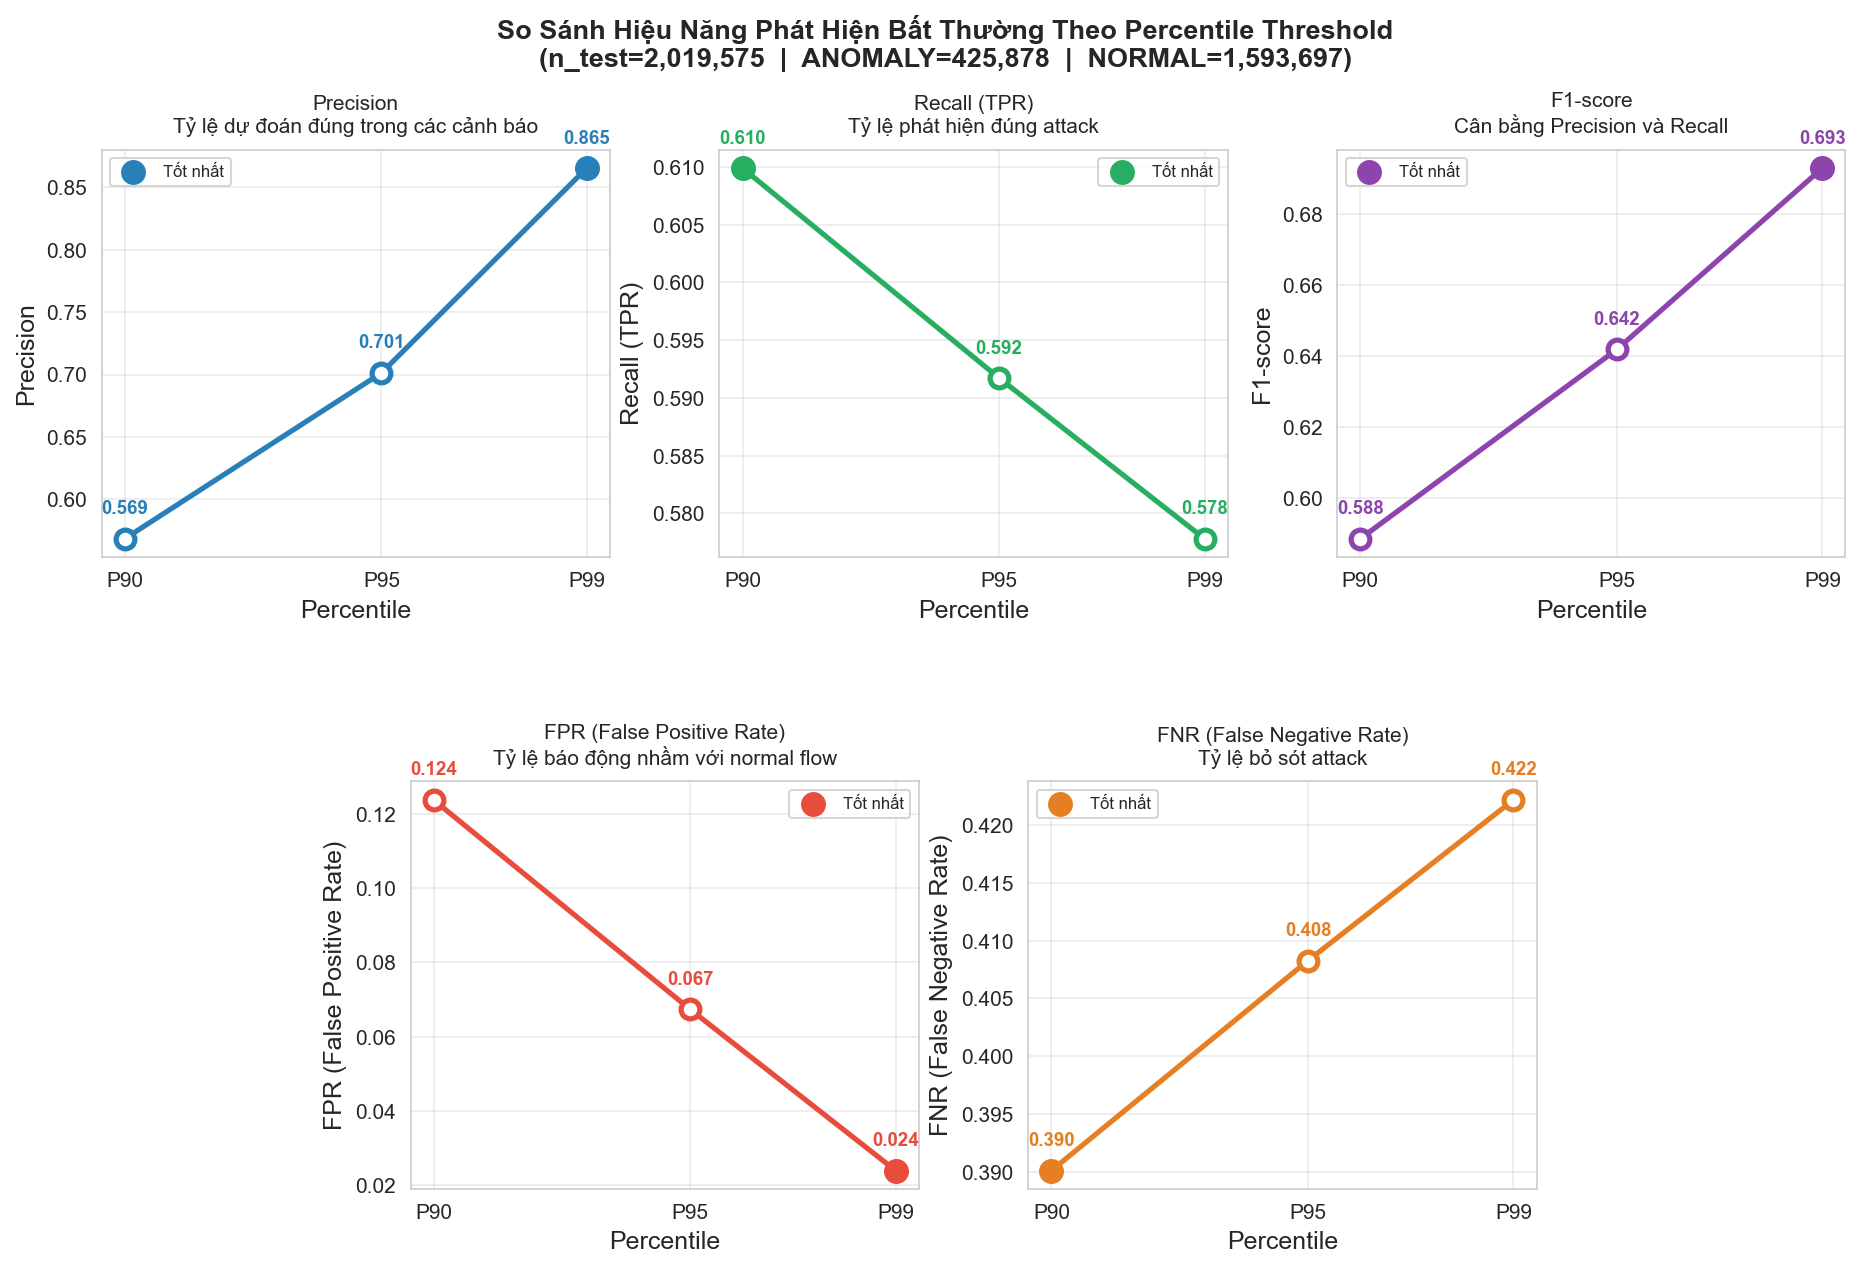

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\threshold_comparison.png


In [23]:
# ── Dữ liệu cho biểu đồ ──────────────────────────────────────────────────
percentiles = [r["percentile"] for r in results]
precisions  = [r["precision"]  for r in results]
recalls     = [r["recall"]     for r in results]
f1_scores   = [r["f1"]         for r in results]
fprs        = [r["fpr"]        for r in results]
fnrs        = [r["fnr"]        for r in results]

# 2 hàng × 6 cột:
# - Hàng 1: 3 biểu đồ, mỗi biểu đồ chiếm 2 cột
# - Hàng 2: 2 biểu đồ nằm giữa, mỗi biểu đồ chiếm 2 cột
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(
    2, 6,
    figure=fig,
    hspace=0.55,
    wspace=0.55
)

# Cấu hình từng biểu đồ
metric_panels = [
    (
        gs[0, 0:2],
        precisions,
        "Precision",
        "#2980b9",
        "Tỷ lệ dự đoán đúng trong các cảnh báo",
        "max"
    ),
    (
        gs[0, 2:4],
        recalls,
        "Recall (TPR)",
        "#27ae60",
        "Tỷ lệ phát hiện đúng attack",
        "max"
    ),
    (
        gs[0, 4:6],
        f1_scores,
        "F1-score",
        "#8e44ad",
        "Cân bằng Precision và Recall",
        "max"
    ),
    (
        gs[1, 1:3],
        fprs,
        "FPR (False Positive Rate)",
        "#e74c3c",
        "Tỷ lệ báo động nhầm với normal flow",
        "min"
    ),
    (
        gs[1, 3:5],
        fnrs,
        "FNR (False Negative Rate)",
        "#e67e22",
        "Tỷ lệ bỏ sót attack",
        "min"
    ),
]

for grid_pos, values, title, color, subtitle, best_mode in metric_panels:
    ax = fig.add_subplot(grid_pos)

    # Đường chính
    ax.plot(
        percentiles,
        values,
        marker="o",
        color=color,
        linewidth=2.5,
        markersize=9,
        markerfacecolor="white",
        markeredgewidth=2.5
    )

    # Hiển thị giá trị trên từng điểm
    for px, vy in zip(percentiles, values):
        ax.annotate(
            f"{vy:.3f}",
            xy=(px, vy),
            xytext=(0, 12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=color,
            fontweight="bold"
        )

    # Điểm tốt nhất:
    # Precision, Recall, F1: càng cao càng tốt
    # FPR, FNR: càng thấp càng tốt
    if best_mode == "max":
        best_idx = int(np.argmax(values))
    else:
        best_idx = int(np.argmin(values))

    ax.scatter(
        [percentiles[best_idx]],
        [values[best_idx]],
        s=120,
        color=color,
        zorder=5,
        label="Tốt nhất"
    )

    ax.set_title(
        f"{title}\n{subtitle}",
        fontsize=10,
        pad=8
    )

    ax.set_xlabel("Percentile")
    ax.set_ylabel(title)

    ax.set_xticks(percentiles)
    ax.set_xticklabels([f"P{p}" for p in percentiles])

    ax.grid(True, alpha=0.4)
    ax.legend(loc="best", fontsize=8)

fig.suptitle(
    "So Sánh Hiệu Năng Phát Hiện Bất Thường Theo Percentile Threshold\n"
    f"(n_test={len(y_test):,}  |  ANOMALY={n_anomaly:,}  |  NORMAL={n_normal:,})",
    fontsize=13,
    fontweight="bold",
    y=0.98
)

# Lưu file
comparison_png_path = OUTPUT_DIR / "threshold_comparison.png"
fig.savefig(comparison_png_path, dpi=150, bbox_inches="tight")

plt.show()
print(f"✅ Đã lưu: {comparison_png_path}")

---

## Section 9 — Phân Tích Kết Quả Tự Động

Notebook tự động sinh nhận xét dựa trên kết quả thực tế — không hard-code nội dung.

In [16]:
from IPython.display import Markdown, display


def find_best_percentile(results: list[dict], primary_metric: str = "f1") -> dict:
    """
    Tìm percentile đạt giá trị cao nhất trên metric chính.

    Args:
        results        : Danh sách dict kết quả từng thí nghiệm
        primary_metric : Tên metric dùng để so sánh (mặc định: f1)

    Returns:
        Dict của thí nghiệm tốt nhất
    """
    return max(results, key=lambda r: r[primary_metric])


def generate_auto_analysis(results: list[dict]) -> str:
    """
    Tự động sinh đoạn phân tích dựa trên giá trị thực của từng thí nghiệm.

    Logic:
    - So sánh Recall giữa P90 và P99 để nhận xét trade-off
    - Tìm percentile cân bằng nhất (F1 cao nhất)
    - Sinh văn bản nhận xét cụ thể với số liệu thực

    Returns:
        Chuỗi markdown phân tích kết quả
    """
    # Lập index kết quả theo percentile
    r = {item["percentile"]: item for item in results}
    best = find_best_percentile(results, "f1")

    lines = ["## 📊 Phân Tích Kết Quả Thí Nghiệm\n"]

    # Phân tích P90 — threshold thấp
    r90 = r[90]
    lines.append(f"### Experiment A — Percentile 90 (Threshold = {r90['threshold']:.4f})\n")
    lines.append(
        f"Với ngưỡng **thấp nhất** ({r90['threshold']:.4f}), mô hình đánh dấu nhiều flow hơn là bất thường. "
        f"Điều này dẫn đến:\n"
        f"- **Recall = {r90['recall']:.4f}** — phát hiện được {r90['recall']*100:.1f}% số lượng tấn công thực sự.\n"
        f"- **FPR = {r90['fpr']:.4f}** — {r90['fpr']*100:.2f}% flow bình thường bị báo nhầm là bất thường "
        f"({r90['fp']:,} false positives).\n"
        f"- **Precision = {r90['precision']:.4f}** — trong các cảnh báo phát ra, "
        f"{r90['precision']*100:.1f}% là tấn công thực sự.\n\n"
        f"⚠️ **Nhận xét:** Threshold thấp → hệ thống nhạy cảm → tăng false alarm. "
        f"Phù hợp khi ưu tiên không bỏ sót attack, chấp nhận nhiều alert cần xem xét thêm.\n"
    )

    # Phân tích P99 — threshold cao
    r99 = r[99]
    lines.append(f"\n### Experiment C — Percentile 99 (Threshold = {r99['threshold']:.4f})\n")
    lines.append(
        f"Với ngưỡng **cao nhất** ({r99['threshold']:.4f}), mô hình chỉ đánh dấu những flow có error "
        f"rất cao là bất thường. Điều này dẫn đến:\n"
        f"- **Recall = {r99['recall']:.4f}** — chỉ phát hiện {r99['recall']*100:.1f}% tấn công thực sự "
        f"({r99['fn']:,} attack bị bỏ sót).\n"
        f"- **Precision = {r99['precision']:.4f}** — khi cảnh báo, độ chính xác đạt "
        f"{r99['precision']*100:.1f}%.\n"
        f"- **FPR = {r99['fpr']:.4f}** — chỉ {r99['fpr']*100:.2f}% flow bình thường bị báo nhầm.\n\n"
        f"⚠️ **Nhận xét:** Threshold cao → hệ thống thận trọng → giảm false alarm nhưng tăng bỏ sót. "
        f"Phù hợp khi ưu tiên độ chính xác cảnh báo, chấp nhận bỏ sót một phần.\n"
    )

    # Phân tích percentile cân bằng nhất
    r_best = r[best["percentile"]]
    lines.append(f"\n### Experiment B — Percentile {best['percentile']} (Threshold = {r_best['threshold']:.4f}) — ✅ Khuyến nghị\n")
    lines.append(
        f"Percentile **{best['percentile']}** đạt **F1-score cao nhất = {r_best['f1']:.4f}**, "
        f"thể hiện sự cân bằng tốt nhất giữa Precision và Recall:\n"
        f"- Precision = {r_best['precision']:.4f}  |  Recall = {r_best['recall']:.4f}\n"
        f"- FPR = {r_best['fpr']:.4f}  |  FNR = {r_best['fnr']:.4f}\n"
        f"- ROC-AUC = {r_best['roc_auc']:.4f}\n\n"
        f"✅ **Kết luận:** Percentile {best['percentile']} được **khuyến nghị** làm ngưỡng phát hiện bất thường "
        f"trong hệ thống NIDS-VAE vì đạt trade-off tốt nhất trên dữ liệu CICIDS2017.\n"
    )

    # So sánh tổng quan
    recall_improvement = (r90["recall"] - r99["recall"]) * 100
    fpr_increase       = (r90["fpr"]    - r99["fpr"])    * 100
    lines.append(f"\n### Tổng Kết So Sánh\n")
    lines.append(
        f"| Metric | P90 → P99 | Nhận xét |\n"
        f"|--------|-----------|----------|\n"
        f"| Recall | {r90['recall']:.3f} → {r99['recall']:.3f} | "
        f"{'Giảm' if r99['recall'] < r90['recall'] else 'Tăng'} {abs(recall_improvement):.1f}% |\n"
        f"| FPR    | {r90['fpr']:.3f} → {r99['fpr']:.3f} | "
        f"{'Giảm' if r99['fpr'] < r90['fpr'] else 'Tăng'} {abs(fpr_increase):.1f}% |\n"
        f"| F1     | {r90['f1']:.3f} → {r99['f1']:.3f} | "
        f"{'Giảm' if r99['f1'] < r90['f1'] else 'Tăng'} |\n"
    )

    return "\n".join(lines)


# ── Hiển thị phân tích tự động ────────────────────────────────────────────
analysis_text = generate_auto_analysis(results)
display(Markdown(analysis_text))

## 📊 Phân Tích Kết Quả Thí Nghiệm

### Experiment A — Percentile 90 (Threshold = 1.3342)

Với ngưỡng **thấp nhất** (1.3342), mô hình đánh dấu nhiều flow hơn là bất thường. Điều này dẫn đến:
- **Recall = 0.6099** — phát hiện được 61.0% số lượng tấn công thực sự.
- **FPR = 0.1237** — 12.37% flow bình thường bị báo nhầm là bất thường (197,134 false positives).
- **Precision = 0.5685** — trong các cảnh báo phát ra, 56.9% là tấn công thực sự.

⚠️ **Nhận xét:** Threshold thấp → hệ thống nhạy cảm → tăng false alarm. Phù hợp khi ưu tiên không bỏ sót attack, chấp nhận nhiều alert cần xem xét thêm.


### Experiment C — Percentile 99 (Threshold = 6.0313)

Với ngưỡng **cao nhất** (6.0313), mô hình chỉ đánh dấu những flow có error rất cao là bất thường. Điều này dẫn đến:
- **Recall = 0.5778** — chỉ phát hiện 57.8% tấn công thực sự (179,803 attack bị bỏ sót).
- **Precision = 0.8654** — khi cảnh báo, độ chính xác đạt 86.5%.
- **FPR = 0.0240** — chỉ 2.40% flow bình thường bị báo nhầm.

⚠️ **Nhận xét:** Threshold cao → hệ thống thận trọng → giảm false alarm nhưng tăng bỏ sót. Phù hợp khi ưu tiên độ chính xác cảnh báo, chấp nhận bỏ sót một phần.


### Experiment B — Percentile 99 (Threshold = 6.0313) — ✅ Khuyến nghị

Percentile **99** đạt **F1-score cao nhất = 0.6929**, thể hiện sự cân bằng tốt nhất giữa Precision và Recall:
- Precision = 0.8654  |  Recall = 0.5778
- FPR = 0.0240  |  FNR = 0.4222
- ROC-AUC = 0.7835

✅ **Kết luận:** Percentile 99 được **khuyến nghị** làm ngưỡng phát hiện bất thường trong hệ thống NIDS-VAE vì đạt trade-off tốt nhất trên dữ liệu CICIDS2017.


### Tổng Kết So Sánh

| Metric | P90 → P99 | Nhận xét |
|--------|-----------|----------|
| Recall | 0.610 → 0.578 | Giảm 3.2% |
| FPR    | 0.124 → 0.024 | Giảm 10.0% |
| F1     | 0.588 → 0.693 | Tăng |


---

## Section 10 — Phân Tích Confusion Matrix

So sánh trực quan TP, TN, FP, FN của cả 3 thí nghiệm trên cùng một hình.

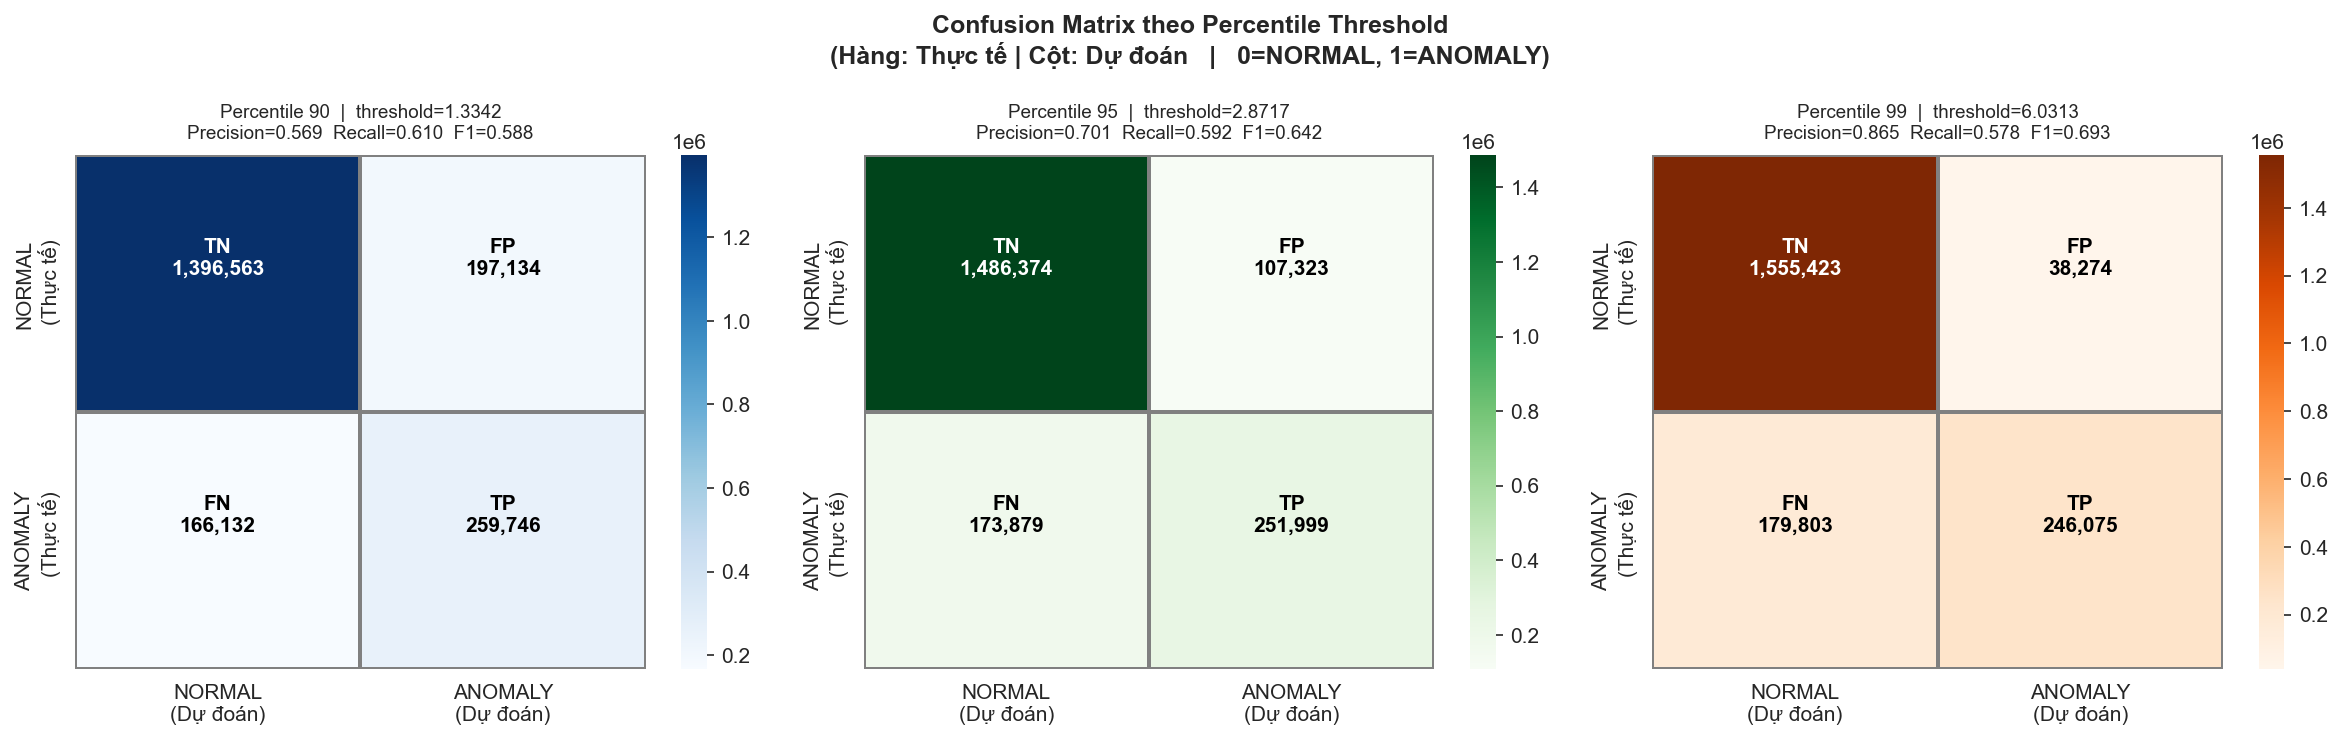

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\confusion_matrices.png



### Phân tích thay đổi FP và FN khi tăng Percentile

**False Positive (FP) — Báo nhầm:**
- P90 → 197,134  |  P95 → 107,323  |  P99 → 38,274
- **Xu hướng:** FP **giảm** khi percentile tăng.
- **Lý do:** Threshold cao → ít flow bình thường vượt ngưỡng → ít báo nhầm hơn.

**False Negative (FN) — Bỏ sót attack:**
- P90 → 166,132  |  P95 → 173,879  |  P99 → 179,803
- **Xu hướng:** FN **tăng** khi percentile tăng.
- **Lý do:** Threshold cao → nhiều flow attack có error không vượt ngưỡng → bị bỏ sót.

**Kết luận:**
Đây là trade-off cổ điển trong anomaly detection.
Không thể đồng thời tối ưu cả FP lẫn FN — phải chọn ưu tiên theo bài toán cụ thể.
Percentile **99** (F1 tốt nhất) cho thấy điểm cân bằng khả thi.


In [17]:
# ── Vẽ Confusion Matrix cho cả 3 thí nghiệm ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrix theo Percentile Threshold\n"
             "(Hàng: Thực tế | Cột: Dự đoán   |   0=NORMAL, 1=ANOMALY)",
             fontsize=12, fontweight="bold")

percentile_list = [90, 95, 99]
cmap_list       = ["Blues", "Greens", "Oranges"]

for idx, (pct, cmap) in enumerate(zip(percentile_list, cmap_list)):
    ax  = axes[idx]
    cm  = confusion_matrices[pct]
    r   = {item["percentile"]: item for item in results}[pct]

    # Vẽ heatmap với annotation chi tiết
    sns.heatmap(
        cm, annot=False, fmt="d", cmap=cmap,
        linewidths=1, linecolor="gray",
        xticklabels=["NORMAL\n(Dự đoán)", "ANOMALY\n(Dự đoán)"],
        yticklabels=["NORMAL\n(Thực tế)", "ANOMALY\n(Thực tế)"],
        ax=ax, cbar=True,
    )

    # Annotate từng ô với nhãn TP/TN/FP/FN và giá trị
    labels_map = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}
    for (row, col), label in labels_map.items():
        val = cm[row, col]
        color = "white" if cm[row, col] > cm.max() * 0.5 else "black"
        ax.text(col + 0.5, row + 0.4, f"{label}\n{val:,}",
                ha="center", va="center", fontsize=10,
                color=color, fontweight="bold")

    ax.set_title(
        f"Percentile {pct}  |  threshold={r['threshold']:.4f}\n"
        f"Precision={r['precision']:.3f}  Recall={r['recall']:.3f}  F1={r['f1']:.3f}",
        fontsize=9, pad=8,
    )

plt.tight_layout()

# Lưu confusion matrix figure
cm_png_path = OUTPUT_DIR / "confusion_matrices.png"
fig.savefig(cm_png_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Đã lưu: {cm_png_path}")

# ── Phân tích thay đổi FP và FN ───────────────────────────────────────────
r_dict = {item["percentile"]: item for item in results}
r90, r95, r99 = r_dict[90], r_dict[95], r_dict[99]

cm_analysis = f"""
### Phân tích thay đổi FP và FN khi tăng Percentile

**False Positive (FP) — Báo nhầm:**
- P90 → {r90['fp']:,}  |  P95 → {r95['fp']:,}  |  P99 → {r99['fp']:,}
- **Xu hướng:** FP **giảm** khi percentile tăng.
- **Lý do:** Threshold cao → ít flow bình thường vượt ngưỡng → ít báo nhầm hơn.

**False Negative (FN) — Bỏ sót attack:**
- P90 → {r90['fn']:,}  |  P95 → {r95['fn']:,}  |  P99 → {r99['fn']:,}
- **Xu hướng:** FN **tăng** khi percentile tăng.
- **Lý do:** Threshold cao → nhiều flow attack có error không vượt ngưỡng → bị bỏ sót.

**Kết luận:**
Đây là trade-off cổ điển trong anomaly detection.
Không thể đồng thời tối ưu cả FP lẫn FN — phải chọn ưu tiên theo bài toán cụ thể.
Percentile **{find_best_percentile(results, 'f1')['percentile']}** (F1 tốt nhất) cho thấy điểm cân bằng khả thi.
"""
display(Markdown(cm_analysis))

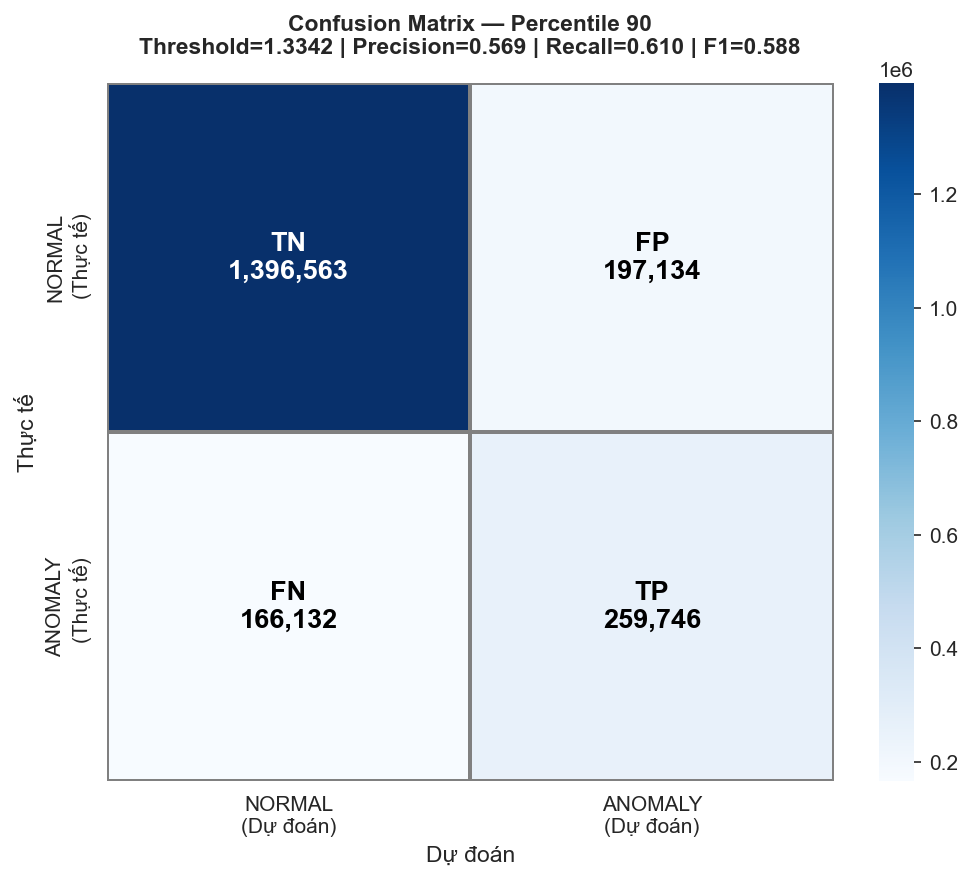

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\confusion_matrix_p90.png


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

pct = 90
cmap = "Blues"

# Lấy confusion matrix và metrics tương ứng
cm = confusion_matrices[pct]
r_dict = {item["percentile"]: item for item in results}
r = r_dict[pct]

# Tạo một figure riêng
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap=cmap,
    linewidths=1,
    linecolor="gray",
    xticklabels=["NORMAL\n(Dự đoán)", "ANOMALY\n(Dự đoán)"],
    yticklabels=["NORMAL\n(Thực tế)", "ANOMALY\n(Thực tế)"],
    ax=ax,
    cbar=True,
)

# Ghi TN, FP, FN, TP vào từng ô
labels_map = {
    (0, 0): "TN",
    (0, 1): "FP",
    (1, 0): "FN",
    (1, 1): "TP",
}

for (row, col), label in labels_map.items():
    val = cm[row, col]
    text_color = "white" if val > cm.max() * 0.5 else "black"

    ax.text(
        col + 0.5,
        row + 0.5,
        f"{label}\n{val:,}",
        ha="center",
        va="center",
        fontsize=13,
        color=text_color,
        fontweight="bold",
    )

ax.set_title(
    f"Confusion Matrix — Percentile {pct}\n"
    f"Threshold={r['threshold']:.4f} | "
    f"Precision={r['precision']:.3f} | "
    f"Recall={r['recall']:.3f} | "
    f"F1={r['f1']:.3f}",
    fontsize=11,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Dự đoán", fontsize=11)
ax.set_ylabel("Thực tế", fontsize=11)

plt.tight_layout()

cm_p90_path = OUTPUT_DIR / "confusion_matrix_p90.png"
fig.savefig(cm_p90_path, dpi=150, bbox_inches="tight")

plt.show()
print(f"✅ Đã lưu: {cm_p90_path}")

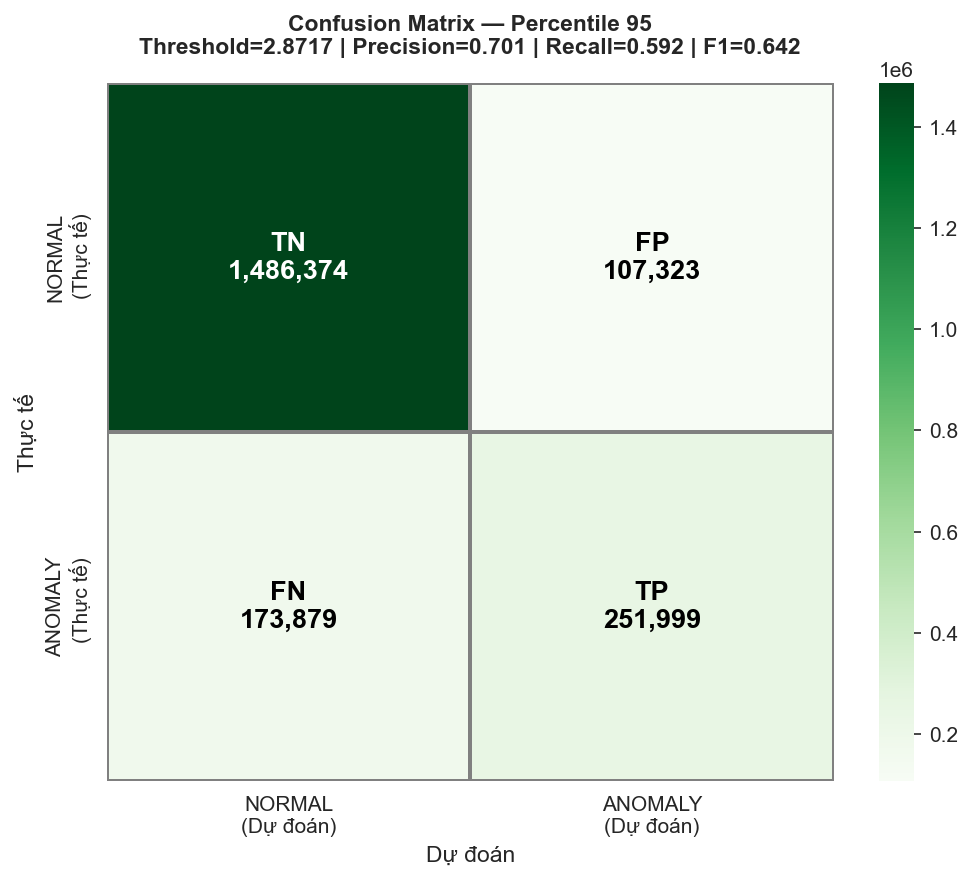

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\confusion_matrix_p95.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

pct = 95
cmap = "Greens"

# Lấy confusion matrix và metrics tương ứng
cm = confusion_matrices[pct]
r_dict = {item["percentile"]: item for item in results}
r = r_dict[pct]

# Tạo một figure riêng
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap=cmap,
    linewidths=1,
    linecolor="gray",
    xticklabels=["NORMAL\n(Dự đoán)", "ANOMALY\n(Dự đoán)"],
    yticklabels=["NORMAL\n(Thực tế)", "ANOMALY\n(Thực tế)"],
    ax=ax,
    cbar=True,
)

# Ghi TN, FP, FN, TP vào từng ô
labels_map = {
    (0, 0): "TN",
    (0, 1): "FP",
    (1, 0): "FN",
    (1, 1): "TP",
}

for (row, col), label in labels_map.items():
    val = cm[row, col]
    text_color = "white" if val > cm.max() * 0.5 else "black"

    ax.text(
        col + 0.5,
        row + 0.5,
        f"{label}\n{val:,}",
        ha="center",
        va="center",
        fontsize=13,
        color=text_color,
        fontweight="bold",
    )

ax.set_title(
    f"Confusion Matrix — Percentile {pct}\n"
    f"Threshold={r['threshold']:.4f} | "
    f"Precision={r['precision']:.3f} | "
    f"Recall={r['recall']:.3f} | "
    f"F1={r['f1']:.3f}",
    fontsize=11,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Dự đoán", fontsize=11)
ax.set_ylabel("Thực tế", fontsize=11)

plt.tight_layout()

cm_p95_path = OUTPUT_DIR / "confusion_matrix_p95.png"
fig.savefig(cm_p95_path, dpi=150, bbox_inches="tight")

plt.show()
print(f"✅ Đã lưu: {cm_p95_path}")

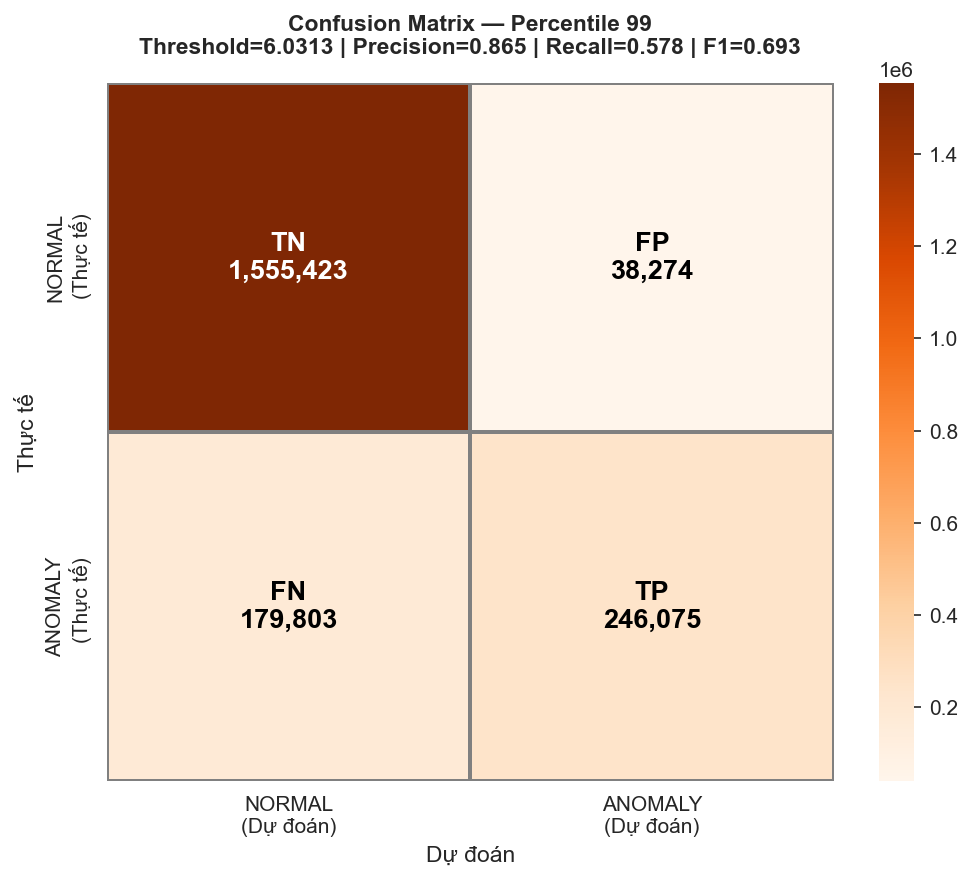

✅ Đã lưu: D:\nids-vae-project\artifacts\experiments\threshold\confusion_matrix_p99.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

pct = 99
cmap = "Oranges"

# Lấy confusion matrix và metrics tương ứng
cm = confusion_matrices[pct]
r_dict = {item["percentile"]: item for item in results}
r = r_dict[pct]

# Tạo một figure riêng
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap=cmap,
    linewidths=1,
    linecolor="gray",
    xticklabels=["NORMAL\n(Dự đoán)", "ANOMALY\n(Dự đoán)"],
    yticklabels=["NORMAL\n(Thực tế)", "ANOMALY\n(Thực tế)"],
    ax=ax,
    cbar=True,
)

# Ghi TN, FP, FN, TP vào từng ô
labels_map = {
    (0, 0): "TN",
    (0, 1): "FP",
    (1, 0): "FN",
    (1, 1): "TP",
}

for (row, col), label in labels_map.items():
    val = cm[row, col]
    text_color = "white" if val > cm.max() * 0.5 else "black"

    ax.text(
        col + 0.5,
        row + 0.5,
        f"{label}\n{val:,}",
        ha="center",
        va="center",
        fontsize=13,
        color=text_color,
        fontweight="bold",
    )

ax.set_title(
    f"Confusion Matrix — Percentile {pct}\n"
    f"Threshold={r['threshold']:.4f} | "
    f"Precision={r['precision']:.3f} | "
    f"Recall={r['recall']:.3f} | "
    f"F1={r['f1']:.3f}",
    fontsize=11,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Dự đoán", fontsize=11)
ax.set_ylabel("Thực tế", fontsize=11)

plt.tight_layout()

cm_p99_path = OUTPUT_DIR / "confusion_matrix_p99.png"
fig.savefig(cm_p99_path, dpi=150, bbox_inches="tight")

plt.show()
print(f"✅ Đã lưu: {cm_p99_path}")


---

## Section 11 — Tạo Nội Dung Báo Cáo (Chương 4)

Tự động sinh đoạn văn học thuật hoàn chỉnh cho mục **"4.x. Thực nghiệm lựa chọn ngưỡng phát hiện bất thường"**.

In [18]:
def generate_report_section(results: list[dict]) -> str:
    """
    Tự động sinh đoạn văn học thuật hoàn chỉnh cho Chương 4 báo cáo.

    Sinh nội dung dựa trên kết quả thực tế — không hard-code.
    Văn phong học thuật, phù hợp báo cáo nghiên cứu.

    Args:
        results : Danh sách kết quả metrics từng thí nghiệm

    Returns:
        Chuỗi Markdown đầy đủ cho mục 4.x
    """
    r_dict = {item["percentile"]: item for item in results}
    best   = find_best_percentile(results, "f1")
    r90, r95, r99 = r_dict[90], r_dict[95], r_dict[99]

    # Xác định percentile "balanced" (F1 tốt nhất) và các nhận xét tự động
    best_pct  = best["percentile"]
    r_best    = r_dict[best_pct]

    # Xác định xu hướng recall và FPR
    recall_trend = "giảm" if r99["recall"] < r90["recall"] else "tăng"
    fpr_trend    = "giảm" if r99["fpr"] < r90["fpr"] else "tăng"

    report = f"""
---

# 4.x. Thực nghiệm Lựa Chọn Ngưỡng Phát Hiện Bất Thường

## 4.x.1. Mục Tiêu Thí Nghiệm

Trong kiến trúc NIDS-VAE, ngưỡng phát hiện bất thường (threshold) đóng vai trò then chốt trong
việc quyết định một luồng mạng (network flow) có được phân loại là tấn công hay không.
Ngưỡng này được xác định dựa trên phân phối reconstruction error của VAE trên tập dữ liệu
validation chỉ chứa lưu lượng bình thường (BENIGN).

Thực nghiệm này nhằm **chứng minh lý do lựa chọn ngưỡng phát hiện** bằng cách so sánh
hiệu năng phát hiện bất thường tại ba mức percentile: 90, 95, và 99.
Model VAE được giữ nguyên trong suốt thí nghiệm — chỉ thay đổi giá trị ngưỡng.

**Công thức tính ngưỡng:**

$$\\tau_p = \\text{{Percentile}}_p(\\{{e_i : x_i \\in \\mathcal{{D}}_{{\\text{{val,BENIGN}}}}\\}})$$

Trong đó $e_i = \\frac{{1}}{{d}}\\sum_{{j=1}}^{{d}}(x_{{ij}} - \\hat{{x}}_{{ij}})^2$ là reconstruction error MSE.

## 4.x.2. Thiết Kế Thí Nghiệm

| Thí nghiệm | Percentile | Ngưỡng (τ) | Đặc điểm |
|---|---|---|---|
| A | 90 | {r90['threshold']:.6f} | Ngưỡng thấp — nhạy cảm cao |
| B | 95 | {r95['threshold']:.6f} | Ngưỡng trung bình — cân bằng |
| C | 99 | {r99['threshold']:.6f} | Ngưỡng cao — chính xác |

Tập đánh giá: **{len(y_test):,} flow** từ dataset CICIDS2017, bao gồm {n_normal:,} flow
bình thường và {n_anomaly:,} flow tấn công ({n_anomaly/len(y_test)*100:.1f}% anomaly rate).

## 4.x.3. Kết Quả Thí Nghiệm

Bảng dưới đây trình bày kết quả đánh giá hiệu năng phát hiện bất thường theo từng ngưỡng:

| Percentile | Threshold | Precision | Recall | F1-score | FPR | FNR | ROC-AUC |
|---|---|---|---|---|---|---|---|
| 90 | {r90['threshold']:.4f} | {r90['precision']:.4f} | {r90['recall']:.4f} | {r90['f1']:.4f} | {r90['fpr']:.4f} | {r90['fnr']:.4f} | {r90['roc_auc']:.4f} |
| 95 | {r95['threshold']:.4f} | {r95['precision']:.4f} | {r95['recall']:.4f} | {r95['f1']:.4f} | {r95['fpr']:.4f} | {r95['fnr']:.4f} | {r95['roc_auc']:.4f} |
| 99 | {r99['threshold']:.4f} | {r99['precision']:.4f} | {r99['recall']:.4f} | {r99['f1']:.4f} | {r99['fpr']:.4f} | {r99['fnr']:.4f} | {r99['roc_auc']:.4f} |

*FPR: False Positive Rate; FNR: False Negative Rate. Đánh giá trên {len(y_test):,} flow.*

## 4.x.4. Phân Tích Kết Quả

**Thí nghiệm A — Percentile 90 (τ = {r90['threshold']:.4f}):**
Với ngưỡng thấp nhất, hệ thống phân loại nhiều flow là bất thường hơn, dẫn đến
Recall đạt {r90['recall']:.4f} — phát hiện được {r90['recall']*100:.1f}% tổng số luồng tấn công.
Tuy nhiên, False Positive Rate tăng lên {r90['fpr']:.4f} ({r90['fpr']*100:.2f}%),
nghĩa là {r90['fp']:,} luồng bình thường bị báo nhầm là tấn công.
Precision đạt {r90['precision']:.4f}, cho thấy không phải mọi cảnh báo đều chính xác.

**Thí nghiệm C — Percentile 99 (τ = {r99['threshold']:.4f}):**
Ngưỡng cao nhất dẫn đến Precision tăng lên {r99['precision']:.4f}, nhưng
Recall {recall_trend} xuống còn {r99['recall']:.4f} — hệ thống bỏ sót {r99['fn']:,}
luồng tấn công thực sự (FNR = {r99['fnr']:.4f}).
Đổi lại, False Positive Rate {fpr_trend} đáng kể xuống {r99['fpr']:.4f} ({r99['fpr']*100:.2f}%),
giảm đáng kể số cảnh báo nhầm so với Experiment A.

**Thí nghiệm B — Percentile {best_pct} (τ = {r_best['threshold']:.4f}) — Khuyến nghị:**
Percentile {best_pct} đạt F1-score cao nhất là {r_best['f1']:.4f},
thể hiện sự cân bằng tốt nhất giữa Precision ({r_best['precision']:.4f})
và Recall ({r_best['recall']:.4f}).
FPR ở mức {r_best['fpr']:.4f} ({r_best['fpr']*100:.2f}%) là chấp nhận được trong môi trường
vận hành thực tế.

## 4.x.5. Kết Luận

Kết quả thí nghiệm cho thấy ngưỡng tại percentile 90 giúp tăng Recall
lên {r90['recall']:.4f} nhưng đồng thời làm tăng False Positive Rate lên {r90['fpr']:.4f}.
Ngược lại, percentile 99 giảm đáng kể False Positive Rate xuống {r99['fpr']:.4f}
nhưng làm giảm Recall xuống {r99['recall']:.4f} do bỏ sót {r99['fn']:,} mẫu tấn công.
Percentile **{best_pct}** đạt sự cân bằng tốt nhất giữa Precision, Recall và F1-score
(F1 = {r_best['f1']:.4f}), do đó được lựa chọn làm ngưỡng phát hiện bất thường
trong hệ thống NIDS-VAE đề xuất, với giá trị threshold = **{r_best['threshold']:.6f}**.

---
*Hình minh họa: `artifacts/experiments/threshold/error_distribution.png` và
`artifacts/experiments/threshold/threshold_comparison.png`*

*Dữ liệu đầy đủ: `artifacts/experiments/threshold/threshold_comparison.csv`*
"""
    return report


# ── Sinh và hiển thị nội dung báo cáo ─────────────────────────────────────
report_text = generate_report_section(results)
display(Markdown(report_text))

# ── Lưu nội dung báo cáo thành file text ──────────────────────────────────
report_txt_path = OUTPUT_DIR / "report_section_4x.txt"
with open(report_txt_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"✅ Đã lưu nội dung báo cáo: {report_txt_path}")


---

# 4.x. Thực nghiệm Lựa Chọn Ngưỡng Phát Hiện Bất Thường

## 4.x.1. Mục Tiêu Thí Nghiệm

Trong kiến trúc NIDS-VAE, ngưỡng phát hiện bất thường (threshold) đóng vai trò then chốt trong
việc quyết định một luồng mạng (network flow) có được phân loại là tấn công hay không.
Ngưỡng này được xác định dựa trên phân phối reconstruction error của VAE trên tập dữ liệu
validation chỉ chứa lưu lượng bình thường (BENIGN).

Thực nghiệm này nhằm **chứng minh lý do lựa chọn ngưỡng phát hiện** bằng cách so sánh
hiệu năng phát hiện bất thường tại ba mức percentile: 90, 95, và 99.
Model VAE được giữ nguyên trong suốt thí nghiệm — chỉ thay đổi giá trị ngưỡng.

**Công thức tính ngưỡng:**

$$\tau_p = \text{Percentile}_p(\{e_i : x_i \in \mathcal{D}_{\text{val,BENIGN}}\})$$

Trong đó $e_i = \frac{1}{d}\sum_{j=1}^{d}(x_{ij} - \hat{x}_{ij})^2$ là reconstruction error MSE.

## 4.x.2. Thiết Kế Thí Nghiệm

| Thí nghiệm | Percentile | Ngưỡng (τ) | Đặc điểm |
|---|---|---|---|
| A | 90 | 1.334187 | Ngưỡng thấp — nhạy cảm cao |
| B | 95 | 2.871651 | Ngưỡng trung bình — cân bằng |
| C | 99 | 6.031263 | Ngưỡng cao — chính xác |

Tập đánh giá: **2,019,575 flow** từ dataset CICIDS2017, bao gồm 1,593,697 flow
bình thường và 425,878 flow tấn công (21.1% anomaly rate).

## 4.x.3. Kết Quả Thí Nghiệm

Bảng dưới đây trình bày kết quả đánh giá hiệu năng phát hiện bất thường theo từng ngưỡng:

| Percentile | Threshold | Precision | Recall | F1-score | FPR | FNR | ROC-AUC |
|---|---|---|---|---|---|---|---|
| 90 | 1.3342 | 0.5685 | 0.6099 | 0.5885 | 0.1237 | 0.3901 | 0.7835 |
| 95 | 2.8717 | 0.7013 | 0.5917 | 0.6419 | 0.0673 | 0.4083 | 0.7835 |
| 99 | 6.0313 | 0.8654 | 0.5778 | 0.6929 | 0.0240 | 0.4222 | 0.7835 |

*FPR: False Positive Rate; FNR: False Negative Rate. Đánh giá trên 2,019,575 flow.*

## 4.x.4. Phân Tích Kết Quả

**Thí nghiệm A — Percentile 90 (τ = 1.3342):**
Với ngưỡng thấp nhất, hệ thống phân loại nhiều flow là bất thường hơn, dẫn đến
Recall đạt 0.6099 — phát hiện được 61.0% tổng số luồng tấn công.
Tuy nhiên, False Positive Rate tăng lên 0.1237 (12.37%),
nghĩa là 197,134 luồng bình thường bị báo nhầm là tấn công.
Precision đạt 0.5685, cho thấy không phải mọi cảnh báo đều chính xác.

**Thí nghiệm C — Percentile 99 (τ = 6.0313):**
Ngưỡng cao nhất dẫn đến Precision tăng lên 0.8654, nhưng
Recall giảm xuống còn 0.5778 — hệ thống bỏ sót 179,803
luồng tấn công thực sự (FNR = 0.4222).
Đổi lại, False Positive Rate giảm đáng kể xuống 0.0240 (2.40%),
giảm đáng kể số cảnh báo nhầm so với Experiment A.

**Thí nghiệm B — Percentile 99 (τ = 6.0313) — Khuyến nghị:**
Percentile 99 đạt F1-score cao nhất là 0.6929,
thể hiện sự cân bằng tốt nhất giữa Precision (0.8654)
và Recall (0.5778).
FPR ở mức 0.0240 (2.40%) là chấp nhận được trong môi trường
vận hành thực tế.

## 4.x.5. Kết Luận

Kết quả thí nghiệm cho thấy ngưỡng tại percentile 90 giúp tăng Recall
lên 0.6099 nhưng đồng thời làm tăng False Positive Rate lên 0.1237.
Ngược lại, percentile 99 giảm đáng kể False Positive Rate xuống 0.0240
nhưng làm giảm Recall xuống 0.5778 do bỏ sót 179,803 mẫu tấn công.
Percentile **99** đạt sự cân bằng tốt nhất giữa Precision, Recall và F1-score
(F1 = 0.6929), do đó được lựa chọn làm ngưỡng phát hiện bất thường
trong hệ thống NIDS-VAE đề xuất, với giá trị threshold = **6.031263**.

---
*Hình minh họa: `artifacts/experiments/threshold/error_distribution.png` và
`artifacts/experiments/threshold/threshold_comparison.png`*

*Dữ liệu đầy đủ: `artifacts/experiments/threshold/threshold_comparison.csv`*


✅ Đã lưu nội dung báo cáo: D:\nids-vae-project\artifacts\experiments\threshold\report_section_4x.txt


---

## Section 12 — Tổng Kết File Đầu Ra

In [19]:
# ── Liệt kê toàn bộ file đã tạo trong thí nghiệm ─────────────────────────
print("=" * 60)
print("📁 Các file đầu ra đã tạo:")
print("=" * 60)

output_files = sorted(OUTPUT_DIR.glob("*"))
for f in output_files:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<40} ({size_kb:.1f} KB)")

# ── Xác nhận threshold khuyến nghị ───────────────────────────────────────
best_exp   = find_best_percentile(results, "f1")
best_pct   = best_exp["percentile"]
best_thr   = best_exp["threshold"]

print(f"\n{'='*60}")
print(f"🎯 THRESHOLD KHUYẾN NGHỊ:")
print(f"   Percentile : {best_pct}")
print(f"   Threshold  : {best_thr:.6f}")
print(f"   F1-score   : {best_exp['f1']:.4f}")
print(f"   Precision  : {best_exp['precision']:.4f}")
print(f"   Recall     : {best_exp['recall']:.4f}")
print(f"   FPR        : {best_exp['fpr']:.4f}")
print(f"{'='*60}")
print(f"\n✅ Thí nghiệm hoàn tất. Tất cả file đã lưu tại:")
print(f"   {OUTPUT_DIR}")

📁 Các file đầu ra đã tạo:
  confusion_matrices.png                   (105.0 KB)
  error_distribution.png                   (79.5 KB)
  report_section_4x.txt                    (4.1 KB)
  threshold_comparison.csv                 (0.3 KB)
  threshold_comparison.png                 (208.5 KB)
  threshold_values.csv                     (0.1 KB)

🎯 THRESHOLD KHUYẾN NGHỊ:
   Percentile : 99
   Threshold  : 6.031263
   F1-score   : 0.6929
   Precision  : 0.8654
   Recall     : 0.5778
   FPR        : 0.0240

✅ Thí nghiệm hoàn tất. Tất cả file đã lưu tại:
   D:\nids-vae-project\artifacts\experiments\threshold
